In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.model_selection import learning_curve

In [42]:
PROJECT_ROOT = Path("../")

MODEL_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"


REPORT_DIR.mkdir(
    exist_ok=True
)

In [43]:
model = joblib.load(
    MODEL_DIR / "best_model.pkl"
)


feature_names = joblib.load(
    MODEL_DIR / "feature_names.pkl"
)


print(model)

ExtraTreesClassifier(random_state=42)


In [70]:
import pandas as pd
import joblib
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"


X_train = pd.read_csv(
    DATA_DIR / "X_train.csv"
)

X_test = pd.read_csv(
    DATA_DIR / "X_test.csv"
)

y_train = pd.read_csv(
    DATA_DIR / "y_train.csv"
).values.ravel()


y_test = pd.read_csv(
    DATA_DIR / "y_test.csv"
).values.ravel()


print(X_train.shape)
print(X_test.shape)

(8000, 23)
(2000, 23)


In [71]:
model = joblib.load(
    MODEL_DIR / "Best_Model.pkl"
)

print("Best model loaded")

Best model loaded


In [44]:
X_test = pd.read_csv(
    DATA_DIR / "X_test.csv"
)


y_test = pd.read_csv(
    DATA_DIR / "y_test.csv"
)


y_test = y_test.squeeze()


print(X_test.shape)
print(y_test.shape)

(2000, 23)
(2000,)


In [45]:
X_test = X_test[
    feature_names
]


print(X_test.shape)

(2000, 23)


In [46]:
y_pred = model.predict(
    X_test
)


y_prob = model.predict_proba(
    X_test
)[:,1]


print("Prediction completed")

Prediction completed


In [47]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [48]:
evaluation = pd.DataFrame({

    "Accuracy":
    [
        accuracy_score(
            y_test,
            y_pred
        )
    ],


    "Precision":
    [
        precision_score(
            y_test,
            y_pred
        )
    ],


    "Recall":
    [
        recall_score(
            y_test,
            y_pred
        )
    ],


    "F1 Score":
    [
        f1_score(
            y_test,
            y_pred
        )
    ],


    "ROC AUC":
    [
        roc_auc_score(
            y_test,
            y_prob
        )
    ],


    "MCC":
    [
        matthews_corrcoef(
            y_test,
            y_pred
        )
    ]

})


evaluation

,Accuracy,Precision,Recall,F1 Score,ROC AUC,MCC
0,0.9985,1.0,0.955882,0.977444,0.993952,0.976934


In [49]:
evaluation.to_csv(
    REPORT_DIR / "model_evaluation.csv",
    index=False
)


print("Evaluation report saved")

Evaluation report saved


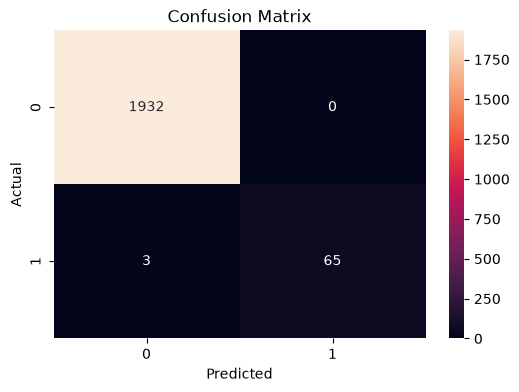

In [50]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(6,4)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)


plt.show()

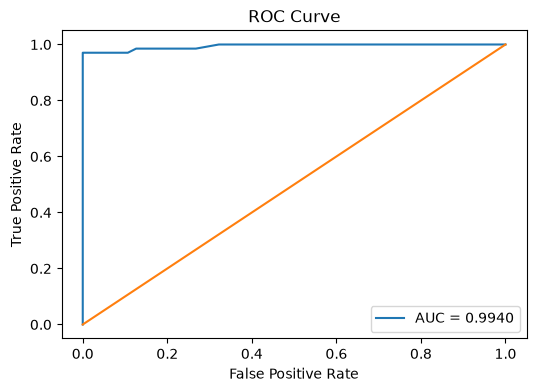

In [51]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


roc_score = auc(
    fpr,
    tpr
)


plt.figure(
    figsize=(6,4)
)


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_score:.4f}"
)


plt.plot(
    [0,1],
    [0,1]
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)


plt.legend()

plt.show()

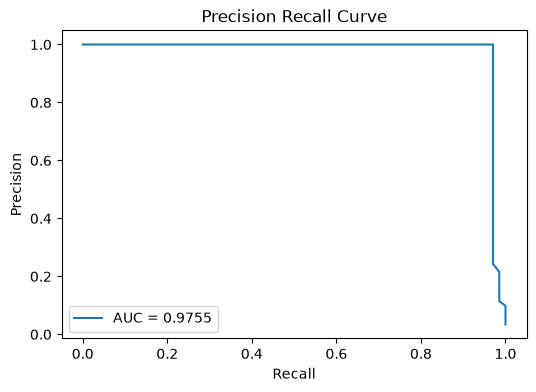

In [52]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)


pr_auc = auc(
    recall,
    precision
)


plt.figure(
    figsize=(6,4)
)


plt.plot(
    recall,
    precision,
    label=f"AUC = {pr_auc:.4f}"
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision Recall Curve"
)


plt.legend()

plt.show()

In [53]:
thresholds = np.arange(
    0.1,
    0.9,
    0.05
)


threshold_results = []


for threshold in thresholds:

    pred = (
        y_prob >= threshold
    ).astype(int)


    threshold_results.append({

        "Threshold":threshold,

        "Precision":
        precision_score(
            y_test,
            pred
        ),

        "Recall":
        recall_score(
            y_test,
            pred
        ),

        "F1":
        f1_score(
            y_test,
            pred
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)


threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.045033,1.000000,0.086185
1,0.15,0.070981,1.000000,0.132554
2,0.20,0.147577,0.985294,0.256705
3,0.25,0.286957,0.970588,0.442953
4,0.30,0.634615,0.970588,0.767442
5,0.35,0.929577,0.970588,0.949640
6,0.40,0.985075,0.970588,0.977778
7,0.45,1.000000,0.970588,0.985075
8,0.50,1.000000,0.955882,0.977444
9,0.55,1.000000,0.882353,0.937500


In [54]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]


best_threshold

Threshold    0.450000
Precision    1.000000
Recall       0.970588
F1           0.985075
Name: 7, dtype: float64

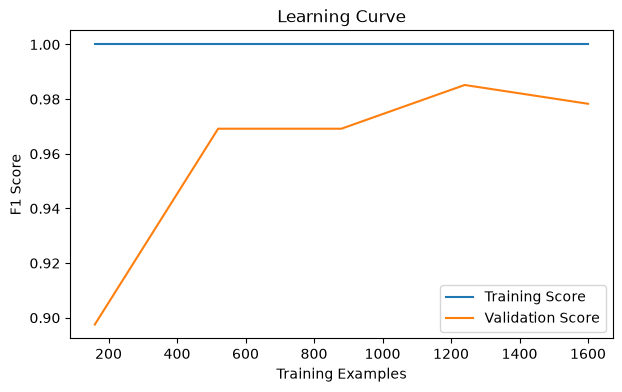

In [55]:
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_test,
    y_test,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)



plt.figure(
    figsize=(7,4)
)


plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)


plt.plot(
    train_sizes,
    test_mean,
    label="Validation Score"
)


plt.xlabel(
    "Training Examples"
)


plt.ylabel(
    "F1 Score"
)


plt.title(
    "Learning Curve"
)


plt.legend()

plt.show()

In [56]:
import shap


explainer = shap.TreeExplainer(
    model
)


shap_values = explainer.shap_values(
    X_test
)


print(type(shap_values))

<class 'numpy.ndarray'>


In [59]:
if len(shap_values.shape) == 3:

    shap_values_failure = shap_values[:, :, 1]

else:

    shap_values_failure = shap_values[1]


print(
    shap_values_failure.shape
)

(2000, 23)


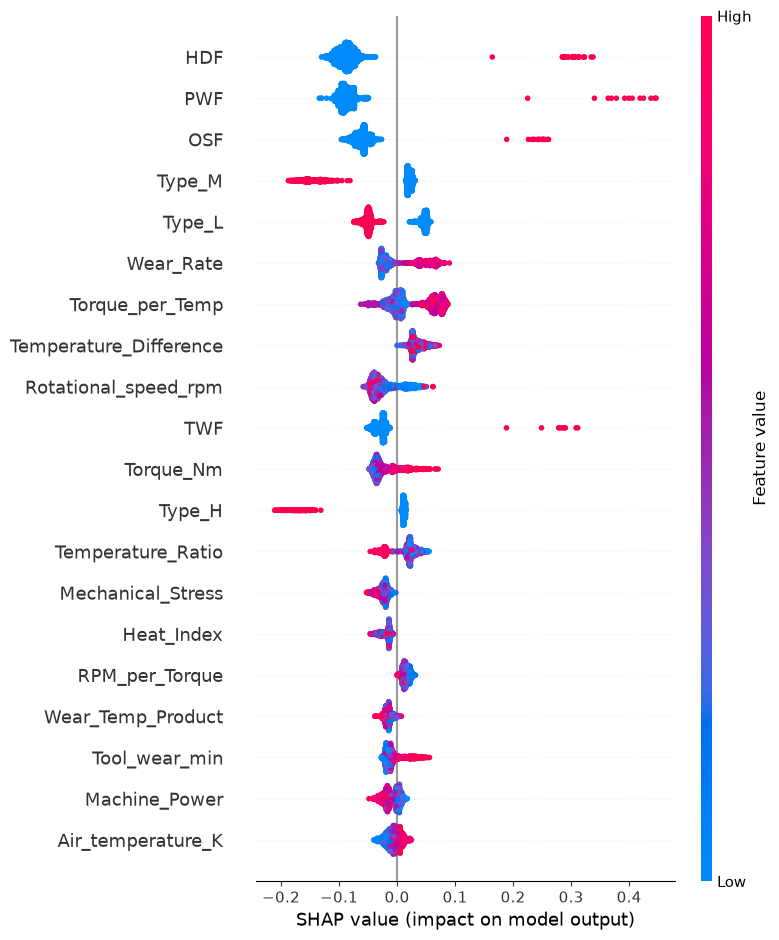

In [60]:
shap.summary_plot(
    shap_values_failure,
    X_test
)

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Convert SHAP values to correct format

if isinstance(shap_values, list):
    shap_values_failure = shap_values[1]

else:
    shap_values_failure = shap_values


# Check dimensions

print("SHAP Shape:", shap_values_failure.shape)
print("X_test Shape:", X_test.shape)


# Fix extra class dimension if present

if len(shap_values_failure.shape) == 3:
    shap_values_failure = shap_values_failure[:, :, 1]


# Create feature importance dataframe

importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance":
    np.abs(shap_values_failure).mean(axis=0)

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


# Save report

importance.to_csv(
    REPORT_DIR / "shap_feature_importance.csv",
    index=False
)


importance.head(15)

SHAP Shape: (2000, 23, 2)
X_test Shape: (2000, 23)


,Feature,Importance
6,HDF,0.091784
7,PWF,0.089537
8,OSF,0.062382
12,Type_M,0.059873
11,Type_L,0.049270
15,Wear_Rate,0.035679
21,Torque_per_Temp,0.034537
13,Temperature_Difference,0.034480
2,Rotational_speed_rpm,0.031159
5,TWF,0.030009


<Figure size 1000x600 with 0 Axes>

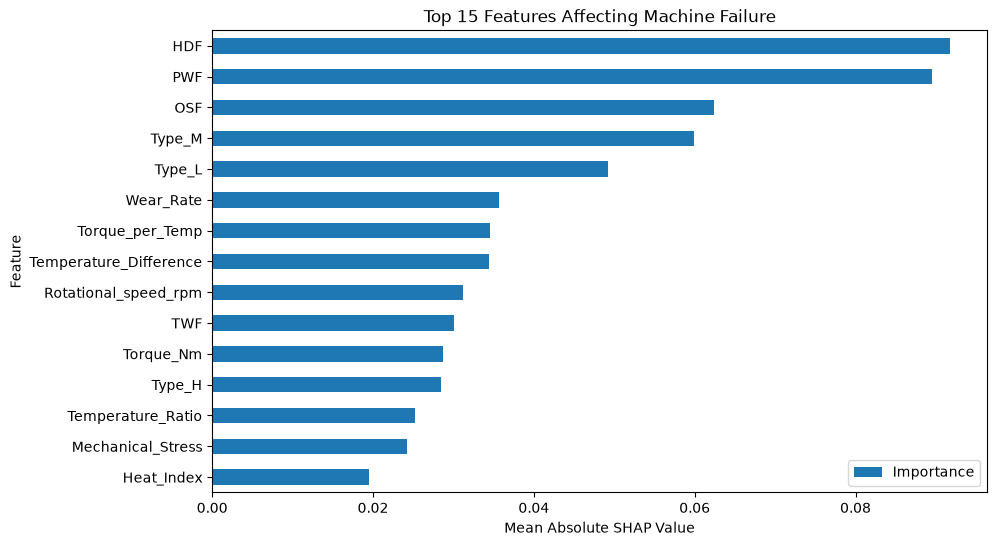

In [63]:
plt.figure(figsize=(10,6))

importance.head(15).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6)
)

plt.title(
    "Top 15 Features Affecting Machine Failure"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.gca().invert_yaxis()

plt.show()

In [66]:
from sklearn.metrics import f1_score
import numpy as np


thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for threshold in thresholds:

    pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_test,
        pred_threshold
    )

    results.append(
        [threshold, score]
    )


threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "F1_Score"
    ]
)


threshold_df.sort_values(
    "F1_Score",
    ascending=False
).head()

,Threshold,F1_Score
7,0.45,0.985075
6,0.40,0.977778
8,0.50,0.977444
5,0.35,0.949640
9,0.55,0.937500


In [67]:
best_threshold = threshold_df.loc[
    threshold_df["F1_Score"].idxmax(),
    "Threshold"
]

best_threshold

np.float64(0.4500000000000001)

In [68]:
final_predictions = (
    y_prob >= best_threshold
).astype(int)


print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



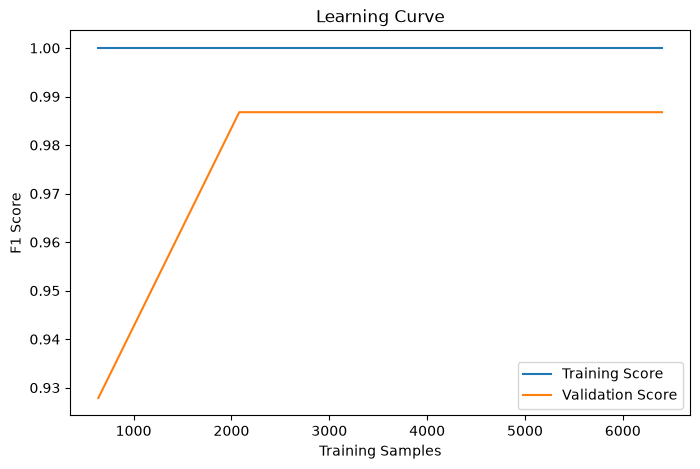

In [72]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt


train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)


plt.plot(
    train_sizes,
    test_mean,
    label="Validation Score"
)


plt.xlabel(
    "Training Samples"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Learning Curve"
)

plt.legend()

plt.show()

In [73]:
final_report = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Score":[

        accuracy_score(
            y_test,
            final_predictions
        ),

        precision_score(
            y_test,
            final_predictions
        ),

        recall_score(
            y_test,
            final_predictions
        ),

        f1_score(
            y_test,
            final_predictions
        ),

        roc_auc_score(
            y_test,
            y_prob
        )
    ]
})


final_report.to_csv(
    REPORT_DIR / "final_model_report.csv",
    index=False
)


final_report

,Metric,Score
0,Accuracy,0.999000
1,Precision,1.000000
2,Recall,0.970588
3,F1 Score,0.985075
4,ROC AUC,0.993952
